### Import Libraries

In [1]:
import joblib
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

### Load the Data

In [2]:
X_train = joblib.load("../../data/processed/X_train_tfidf.pkl")
X_val = joblib.load("../../data/processed/X_val_tfidf.pkl")
X_test = joblib.load("../../data/processed/X_test_tfidf.pkl")

y_train = joblib.load("../../data/processed/y_train.pkl")
y_val = joblib.load("../../data/processed/y_val.pkl")
y_test = joblib.load("../../data/processed/y_test.pkl")

### Build the Random Forest Model

In [3]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Training Accuracy

In [4]:
y_train_pred = rf_model.predict(X_train)

train_accuracy = accuracy_score(y_train, y_train_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")

Training Accuracy: 0.9950


### Validation Accuracy

In [5]:
y_val_pred = rf_model.predict(X_val)

val_accuracy = accuracy_score(y_val, y_val_pred)

print(f"Validation Accuracy: {val_accuracy:.4f}")

Validation Accuracy: 0.9410


### Test Accuracy

In [6]:
y_test_pred = rf_model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.9417


In [7]:
print(f"Training Accuracy   : {train_accuracy:.4f}")
print(f"Validation Accuracy : {val_accuracy:.4f}")
print(f"Test Accuracy       : {test_accuracy:.4f}")

Training Accuracy   : 0.9950
Validation Accuracy : 0.9410
Test Accuracy       : 0.9417


### Classification Report

In [8]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

    Negative       0.93      0.43      0.58       347
     Neutral       0.70      0.29      0.41       388
    Positive       0.95      0.99      0.97      8223

    accuracy                           0.94      8958
   macro avg       0.86      0.57      0.65      8958
weighted avg       0.94      0.94      0.93      8958



### Confusion Matrix

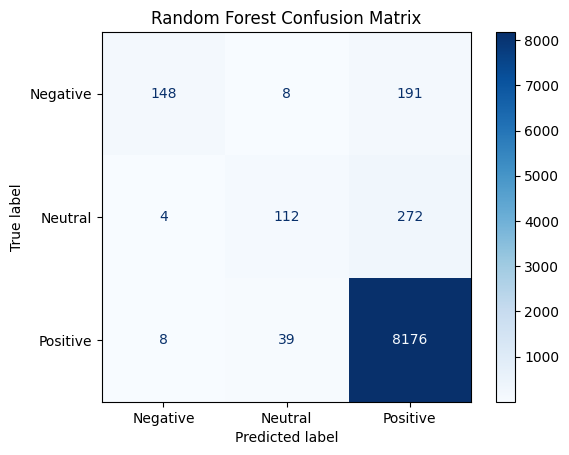

In [9]:
cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=rf_model.classes_
)

disp.plot(cmap="Blues")

plt.title("Random Forest Confusion Matrix")

plt.show()

### Save the model

In [10]:
joblib.dump(
    rf_model,
    "../../models/random_forest.pkl"
)

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


### Conclusion
The Random Forest classifier achieved a training accuracy of 99.50%, a validation accuracy of 94.10%, and a test accuracy of 94.17%. The high training accuracy compared to the validation and test accuracies indicates mild overfitting. However, the close agreement between the validation and test results suggests that the model still generalizes well to unseen data and provides strong predictive performance.